✅ Step 1: Load and Normalize the Dataset

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# Normalize the features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)


✅ Step 2: Train-Test Split



In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)


✅ Step 3: KNN Classification

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Try different K values
k_values = [1, 3, 5, 7]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    print(f"\nK = {k}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



K = 1
Accuracy: 0.9666666666666667
Confusion Matrix:
 [[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]

K = 3
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

K = 5
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

K = 7
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


✅ Step 4: Visualize Decision Boundaries (2 Features)

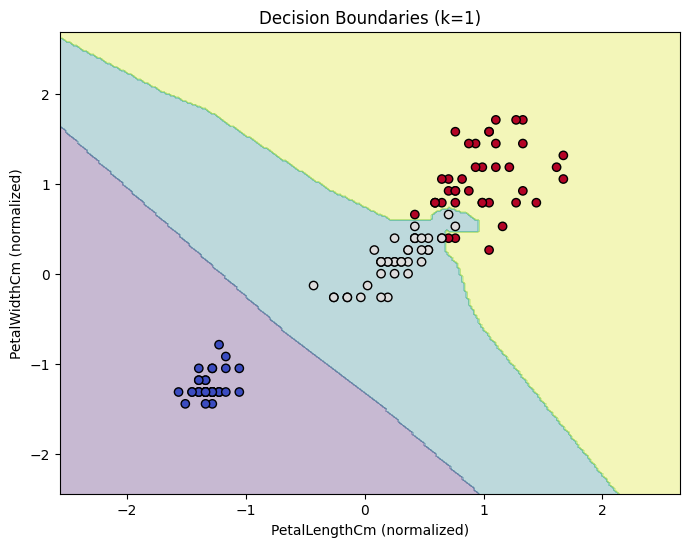

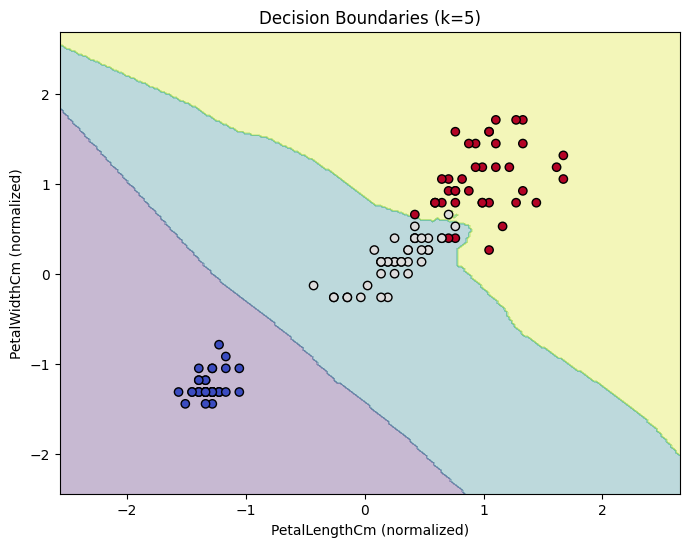

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Use only 2 features
X_vis = X[:, [2, 3]]
X_vis = StandardScaler().fit_transform(X_vis)
X_train, X_test, y_train, y_test = train_test_split(X_vis, y, test_size=0.2, random_state=42)

# Plot function
def plot_decision_boundaries(X, y, model, k):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
    plt.title(f"Decision Boundaries (k={k})")
    plt.xlabel('PetalLengthCm (normalized)')
    plt.ylabel('PetalWidthCm (normalized)')
    plt.show()

# Train and plot
for k in [1, 5]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    plot_decision_boundaries(X_train, y_train, model, k)
